# Introduction

This notebook assumes you have activated credentials with the CAVE client. CAVE (Connectome Annotation Versioning Engine) is built and supported by a collaboration between the Seung lab at Princeton and the Allen Institute for Brain Science. It allows for programmatic access to the tables associated with Minnie and other datasets. [Github](https://github.com/seung-lab/CAVEclient) 

CAVE setup instructions are [here](https://github.com/AllenInstitute/MicronsBinder/blob/master/notebooks/mm3_intro/CAVEsetup.ipynb).

CAVE tutorial for querying the data is [here](https://github.com/AllenInstitute/MicronsBinder/blob/master/notebooks/mm3_intro/SynapseAndAnnotationQuery.ipynb).

## Using CAVEclient to query data

In [2]:
from caveclient import CAVEclient

Load the public client for accessing the datastack in CAVE. If you have not acquired an authentication token, run the code below to get a new token. You will need to link your Google account.

In [3]:
client = CAVEclient()
# client.auth.get_new_token()
client.auth.setup_token(make_new=False)
client.auth.save_token(token="6726f7ba8d8f65c4d0fd93b529184bbb")

Tokens need to be acquired by hand. Please follow the following steps:
                1) Go to: https://global.daf-apis.com/sticky_auth/settings/tokens to view a list of your existing tokens.
                2) Log in with your Google credentials copy one of the tokens from the dictionary (the string under the key 'token').
                3a) Save it to your computer with: client.auth.save_token(token="PASTE_YOUR_TOKEN_HERE")
                or
                3b) Set it for the current session only with client.auth.token = "PASTE_YOUR_TOKEN_HERE"
                Note: If you need to save or load multiple tokens, please read the documentation for details.
                if you want to create a new token, or have no token use ```self.get_new_token``` instead
                or use this function with the keyword argument make_new=True


ValueError: Key "token" already exists in token file "/home/vscode/.cloudvolume/secrets/global.daf-apis.com-cave-secret.json"

If you have successfully added your token or already have a valid token saved from a previous session, you should be able to initialize the client with the `minnie65_public` datastack:

```python
client = CAVEclient('minnie65_public')
```

If your previous saved token is invalidated, you will need to save your newly acquired token with the argument `overwrite=True`.

```python
client.auth.save_token(token="PASTE_YOUR_TOKEN_HERE", overwrite=True)
```

In [4]:
# this is the datastack name of the public release
# passing it will auto-configure many of the services
client = CAVEclient('minnie65_public')
print(client.materialize.get_versions())

[1300, 1078, 117, 661, 343, 1181, 795, 943, 1412, 1507, 1621, 1718]


### Setting the version of the public release

With the initialized client, set the version of the public release:

```python
client.materialize.version = VERSION
```

Table names and data will change between versions. This notebook is built around version `661`. To use a later version, find the corresponding tables in the new version. 

In [5]:
client.materialize.version = 1718  # set to latest version

### View available annotation tables

In [6]:
client.materialize.get_tables()

['synapses_pni_2',
 'nucleus_detection_v0',
 'vortex_manual_nodes_of_ranvier',
 'bodor_pt_target_proofread',
 'baylor_gnn_cell_type_fine_model_v2',
 'nucleus_alternative_points',
 'nucleus_functional_area_assignment',
 'coregistration_auto_phase3_fwd_apl_vess_combined_v2',
 'aibs_metamodel_mtypes_v661_v2_corrections',
 'vortex_thalamic_proofreading_status',
 'allen_column_mtypes_v2',
 'proofreading_status_and_strategy',
 'bodor_pt_cells',
 'aibs_metamodel_mtypes_v661_v2',
 'aibs_metamodel_celltypes_v661_corrections',
 'vortex_microglia_proofreading_status',
 'allen_v1_column_types_slanted_ref',
 'multi_input_spine_predictions_ssa',
 'aibs_column_nonneuronal_ref',
 'nucleus_ref_neuron_svm',
 'synapse_target_structure',
 'myelin_auto_tags_2points',
 'apl_functional_coreg_vess_fwd',
 'vortex_axon_backtrace_column',
 'cell_type_multifeature_combo',
 'vortex_compartment_targets',
 'baylor_log_reg_cell_type_coarse_v1',
 'vortex_synapse_reattachment',
 'coregistration_auto_phase3_fwd_v2',
 's

### Query functionally matched EM neurons

In [ ]:
import pandas as pd

In [8]:
matched_df = client.materialize.query_table('coregistration_manual_v4') 
matched_df

,id,created,valid,target_id,session,scan_idx,unit_id,field,residual,score,id_ref,created_ref,valid_ref,volume,pt_supervoxel_id,pt_root_id,pt_position,bb_start_position,bb_end_position
0,5491,2024-05-21 18:38:25.372047+00:00,True,335649,6,2,6883,6,7.41244,2.60806,335649,2020-09-28 22:41:20.303372+00:00,True,295.861115,93747454767483710,864691135702330235,"[210784, 182032, 22673]","[<NA>, <NA>, <NA>]","[<NA>, <NA>, <NA>]"
1,12542,2024-05-21 18:42:40.285576+00:00,True,194144,7,4,9575,6,8.55708,-0.7149,194144,2020-09-28 22:42:01.511773+00:00,True,213.307236,83542405709639148,864691135614842827,"[136400, 170640, 17951]","[<NA>, <NA>, <NA>]","[<NA>, <NA>, <NA>]"
2,15097,2024-05-21 18:42:41.703496+00:00,True,194144,8,5,8632,6,4.25055,7.87525,194144,2020-09-28 22:42:01.511773+00:00,True,213.307236,83542405709639148,864691135614842827,"[136400, 170640, 17951]","[<NA>, <NA>, <NA>]","[<NA>, <NA>, <NA>]"
3,12829,2024-05-21 18:42:40.443453+00:00,True,517966,7,5,1526,2,5.8237,4.16608,517966,2020-09-28 22:41:48.288009+00:00,True,313.318939,107530794289274882,864691136966116814,"[310944, 115888, 16752]","[<NA>, <NA>, <NA>]","[<NA>, <NA>, <NA>]"
4,10490,2024-05-21 18:42:39.170710+00:00,True,224395,7,3,2398,2,7.02217,-1.39408,224395,2020-09-28 22:41:32.572651+00:00,True,329.448334,85366977140498420,864691135686521271,"[149840, 133152, 22592]","[<NA>, <NA>, <NA>]","[<NA>, <NA>, <NA>]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19176,9135,2024-05-21 18:42:31.481457+00:00,True,328140,6,7,3661,4,6.42422,7.30218,328140,2020-09-28 22:43:27.427858+00:00,True,111.254242,93460413110868831,864691135698390426,"[208704, 140592, 19918]","[<NA>, <NA>, <NA>]","[<NA>, <NA>, <NA>]"
19177,11239,2024-05-21 18:42:39.579247+00:00,True,432639,7,3,9049,8,3.66317,8.00223,432639,2020-09-28 22:45:25.114887+00:00,True,471.135834,99096991153416272,864691136053680883,"[249632, 193648, 22635]","[<NA>, <NA>, <NA>]","[<NA>, <NA>, <NA>]"
19178,4356,2024-05-21 18:38:24.733806+00:00,True,269593,5,7,8524,8,6.45214,9.54236,269593,2020-09-28 22:43:30.133113+00:00,True,317.925446,88475090421070247,864691135480311494,"[172464, 221888, 23253]","[<NA>, <NA>, <NA>]","[<NA>, <NA>, <NA>]"
19179,10086,2024-05-21 18:42:38.950318+00:00,True,269402,6,7,8235,8,7.12704,12.27556,269402,2020-09-28 22:41:42.679084+00:00,True,311.959564,88473715830302301,864691136425073455,"[172480, 211312, 21821]","[<NA>, <NA>, <NA>]","[<NA>, <NA>, <NA>]"


### Column descriptions:

<b>id:</b> a unique identifier for this row

<b>valid:</b> internal check, uniformly ‘t’

<b>pt_supervoxel_id:</b> the ID of the supervoxel from the watershed segmentation that is under the pt_position

<b>pt_root_id:</b> the ID of the segment/root_id under the pt_position from the Proofread Segmentation (v343).

<b>session:</b> the ID indicating the imaging period for the mouse

<b>scan_idx:</b> the index of the scan within the imaging session

<b>unit_id:</b> the ID of the functional ROI (unique per scan)

<b>pt_position_{x,y,z}:</b> the location in 4,4,40 nm voxels at a cell body for the cell

<b>residual:</b> the Euclidean distance between the EM nucleus centroid and the matched functional centroid after the AIBS EM -> 2P coregistration transform

<b>separation:</b> For a matched EM nucleus to a functional unit the separation score is computed as the difference between the residual of the matched pair and the residual of the nearest EM neuronal nucleus that was not matched to the unit.

Note: More confident matches will have a smaller residual and larger separation

### Select a random entry

In [8]:
entry = matched_df.sample(1)
entry

,id,created,valid,target_id,session,scan_idx,unit_id,field,residual,score,id_ref,created_ref,valid_ref,volume,pt_supervoxel_id,pt_root_id,pt_position,bb_start_position,bb_end_position
15137,8550,2024-05-21 18:38:27.079345+00:00,True,524664,6,6,7292,6,8.11695,4.18555,524664,2020-09-28 22:45:11.646650+00:00,True,335.269897,105849160309571506,864691135578032389,"[299024, 169248, 19251]","[<NA>, <NA>, <NA>]","[<NA>, <NA>, <NA>]"


In [9]:
segment = entry.pt_root_id.values[0] # get ID of segment to visualize
centroid = entry.pt_position.values[0] # get centroid of segment

## View entry in Neuroglancer

Programmatic editing of Neuroglancer links can be accomplished using the Seung lab/ AIBS package [nglui](https://github.com/seung-lab/NeuroglancerAnnotationUI).

[Example notebook](https://github.com/seung-lab/NeuroglancerAnnotationUI/blob/master/examples/statebuilder_examples.ipynb)

In [10]:
# generate links in Seung lab a custom Neuroglancer deployment called Neuromancer
from nglui import statebuilder, EasyViewer 

viewer = EasyViewer()
viewer.set_resolution((4,4,40))

em_layer = statebuilder.ImageLayerConfig(client.info.image_source(), 
                                         contrast_controls=True, black=0.35, white=0.7) # set EM layer 
seg_layer =  statebuilder.SegmentationLayerConfig(client.info.segmentation_source(),  
                                                  name='seg', fixed_ids=[segment]) # set dynamic segmentation layer
view_kws = {'layout': '3d',
            'zoom_3d': 3000,
            'position': centroid}  # set zoom options and center on segment

sb = statebuilder.StateBuilder([em_layer, seg_layer], view_kws=view_kws) # generate statebuilder
sb.render_state(return_as='html', base_state=viewer.state) # render state as html link


# Access Functional data

This notebook assumes you have access to a copy of the SQL database that houses the functional data and the functional data schema repository. Instructions to download are [here](https://www.microns-explorer.org/cortical-mm3#f-data).

The contents of the SQL schema are accessed programmatically using [DataJoint](https://datajoint.io/). Find an example notebook for using DataJoint to access the functional data [here](Using_DataJoint_to_Access_Functional_Data.ipynb).

In [ ]:
from microns_phase3 import nda, utils
import numpy as np
import matplotlib.pyplot as plt
import datajoint as dj

Connecting microns@db.datajoint.com:3306


# ERD
### Entity relationship diagram. Tables as nodes and dependencies as directed edges.

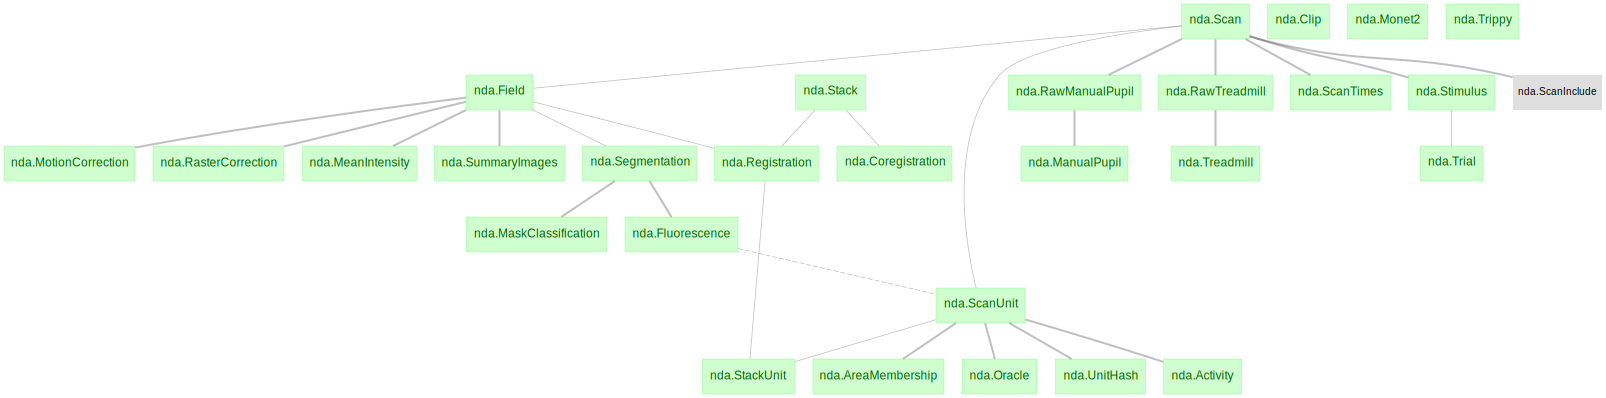

In [15]:
dj.ERD(nda)

## Some examples of tables in the DataJoint, exploring functional data

In [ ]:
nda.Scan()
# [*nda.Scan.heading.primary_key] # primary keys 
# scan_key = {'session': 4, 'scan_idx': 7} # dictionary to restrict table entries
# nda.Scan & scan_key
# scan_keys = [{'session': 4, 'scan_idx': 7}, {'session': 5, 'scan_idx': 3}] # restrict to multiple entries
# nda.Scan & scan_keys

# # fetch info from scans (use fetch1 if want just one scan)
# nframes, nfields = (nda.Scan & scan_keys).fetch('nframes', 'nfields')
# print(f'number of frames in these scans: {nframes}, number of fields in these scans: {nfields}')

# nda.Scan & nda.ScanInclude # scans only for analysis
# nda.Field & scan_key # each scan can have multiple imaging fields

number of frames in these scans: [40000 40000], number of fields in these scans: [8 8]


session Session ID,scan_idx Scan ID,field Field Number,px_width field pixels per line,px_height lines per field,um_width field width (microns),um_height field height (microns),field_x field x motor coordinates (microns),field_y field y motor coordinates (microns),field_z field z motor coordinates (microns)
4,7,1,248,440,620.0,1100.0,-485.0,-235.0,80.0
4,7,2,248,440,620.0,1100.0,95.0,-235.0,80.0
4,7,3,248,440,620.0,1100.0,-485.0,-235.0,220.0
4,7,4,248,440,620.0,1100.0,95.0,-235.0,220.0
4,7,5,248,440,620.0,1100.0,-485.0,-235.0,360.0
4,7,6,248,440,620.0,1100.0,95.0,-235.0,360.0
4,7,7,248,440,620.0,1100.0,-485.0,-235.0,500.0
4,7,8,248,440,620.0,1100.0,95.0,-235.0,500.0


Trial starts at index: 625 and ends at index 719


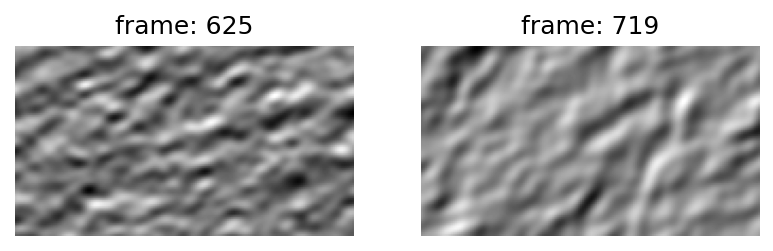

In [27]:
# lets look at some of the movie stimuli
trial_key = {'session': 4, 'scan_idx': 7, 'trial_idx': 8}
trial_info = nda.Trial & trial_key
start, end = (trial_info * nda.Monet2).fetch1('start_idx', 'end_idx') # Fetch indices of trial
print(f'Trial starts at index: {start} and ends at index {end}')

movie = (nda.Stimulus & scan_key).fetch1('movie') # stimulus images synchronized with nda.ScanTimes
stimulus_trial_slice = movie[:,:,slice(start, end)] # slice movie according to indices of trial
fig, axs = plt.subplots(1, 2, dpi=150) # view first and last frame of movie slice
axs[0].imshow(stimulus_trial_slice[:,:,0], cmap='gray')
axs[0].set_title(f'frame: {start}')
axs[1].imshow(stimulus_trial_slice[:,:,-1], cmap='gray')
axs[1].set_title(f'frame: {end}')
[ax.axis('off') for ax in axs];

In [40]:
(nda.RawManualPupil() & scan_key).fetch1("pupil_times")
# (nda.RawTreadmill & scan_key).fetch1("treadmill_timestamps")

array([-10.0084427,  -9.9083672,  -9.8583672, ...,         nan,
               nan,         nan])

## Summary images

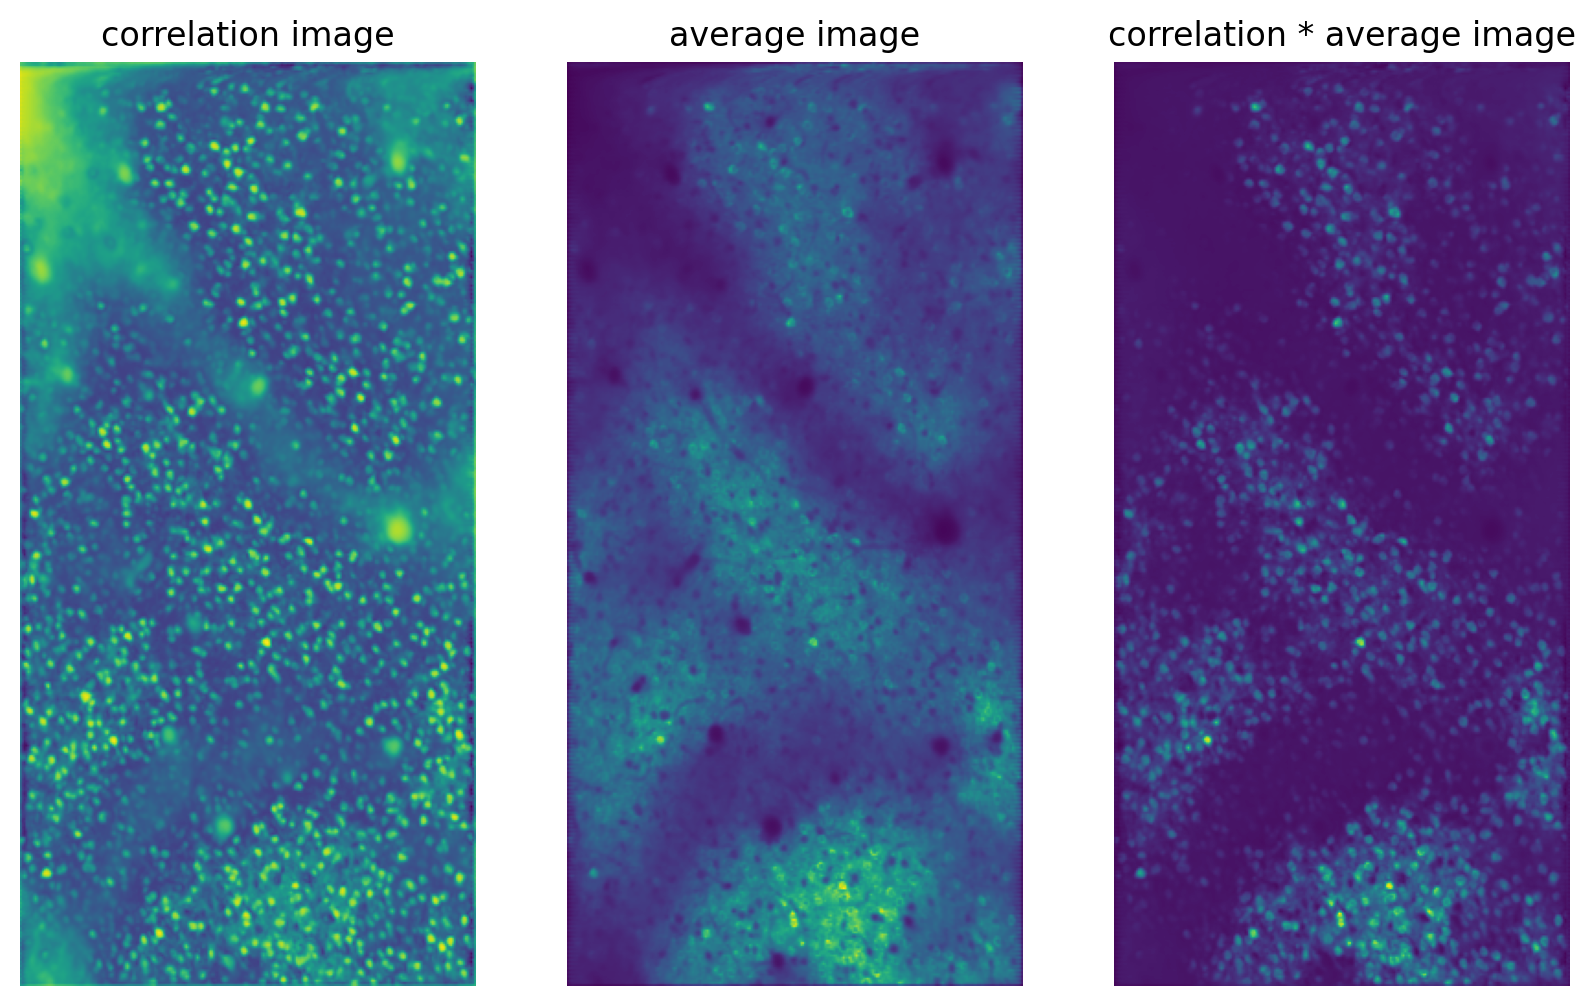

In [43]:
field_key = {'session': 4, 'scan_idx': 7, 'field': 4}
corr, avg = (nda.SummaryImages & field_key).fetch1('correlation', 'average')

fig, axs = plt.subplots(1, 3, figsize=(10,6), dpi=200)
axs[0].imshow(corr)
axs[0].set_title('correlation image')
axs[1].imshow(avg)
axs[1].set_title('average image')
axs[2].imshow(corr*avg) # gives a good view of the cell bodies and darkens vessels
axs[2].set_title('correlation * average image')
[ax.axis('off') for ax in axs];
[ax.set_aspect('auto') for ax in axs];

## Mean Intensity
The mean intensity of the calcium signal for the entire field is computed per frame for the duration of the scan. This is found in `nda.MeanIntensity`. Periods of low intensity may indicate a low quality stretch of scan, for example where water might have temporarily run out between the microscope objective and imaging site.

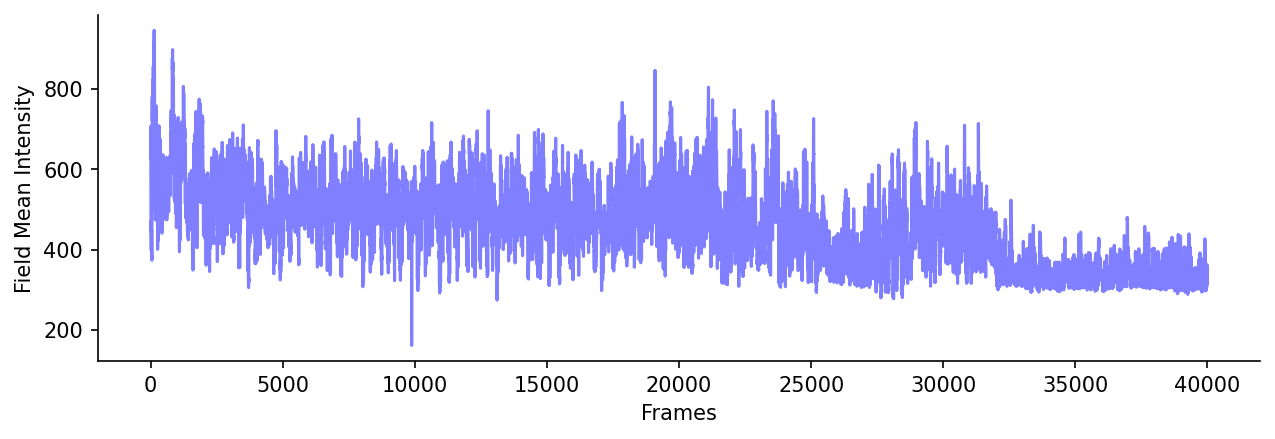

In [45]:
intensities = (nda.MeanIntensity & field_key).fetch1('intensities')
fig, ax = plt.subplots(figsize=(10, 3), dpi=150)
ax.plot(intensities, c='b', alpha=0.5)
ax.set_xlabel('Frames')
ax.set_ylabel('Field Mean Intensity')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

### Masks
The functional ROI segmentation gives a set of 2D masks indexed by `mask_id`, which are unique per `field`. A cell that was scanned in more than one imaging field will have more than one mask. Masks are stored in `nda.Segmentation`. Classification of masks as `soma` or `artifact` is stored in `nda.MaskClassification`. See technical documentation for further details on segmentation and classification methods.

In [46]:
nda.Segmentation * nda.MaskClassification & field_key

session Session ID,scan_idx Scan ID,field Field Number,"mask_id mask ID, unique per field",pixels indices into the image in column major (Fortran) order,weights weights of the mask at the indices above,mask_type classification of mask as soma or artifact
4,7,4,1,=BLOB=,=BLOB=,artifact
4,7,4,2,=BLOB=,=BLOB=,soma
4,7,4,3,=BLOB=,=BLOB=,soma
4,7,4,4,=BLOB=,=BLOB=,artifact
4,7,4,5,=BLOB=,=BLOB=,soma
4,7,4,6,=BLOB=,=BLOB=,soma
4,7,4,7,=BLOB=,=BLOB=,soma
4,7,4,8,=BLOB=,=BLOB=,soma
4,7,4,9,=BLOB=,=BLOB=,artifact
4,7,4,10,=BLOB=,=BLOB=,artifact


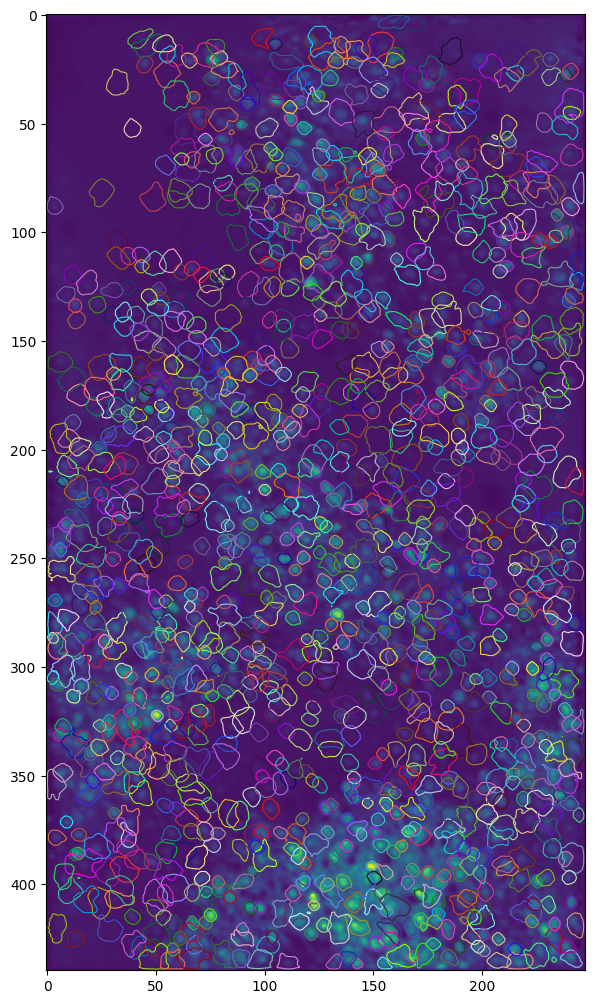

In [47]:
masks = utils.get_all_masks(field_key, mask_type='soma', plot=True) # function that will retrieve masks in convenient format and optionally plot

### Calcium fluorescence traces 
Each mask has a GCaMP6 fluorescence trace in nda.Fluorescence.

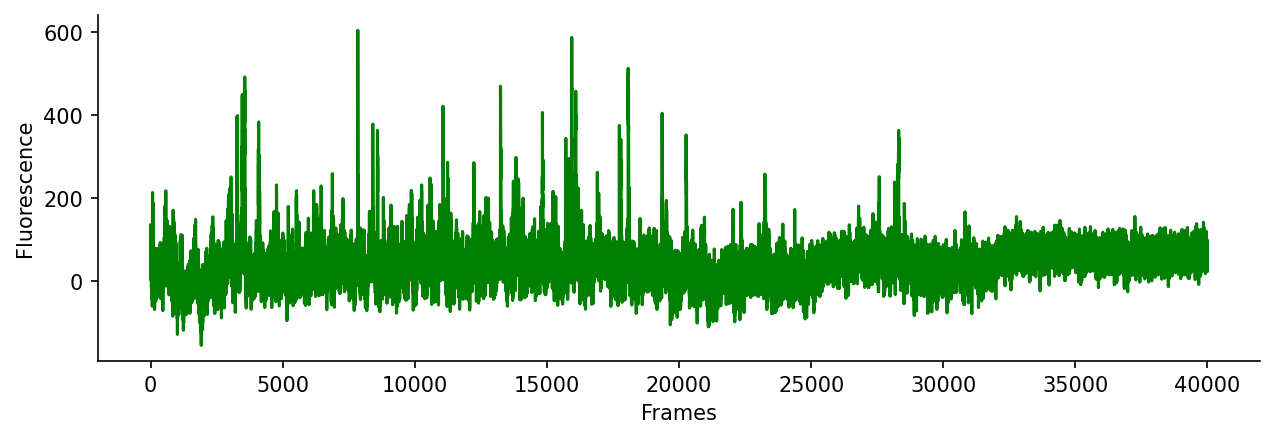

In [48]:
calcium_trace = (nda.Fluorescence() & field_key & {'mask_id': 500}).fetch1('trace')

fig, ax = plt.subplots(figsize=(10, 3), dpi=150)
ax.plot(calcium_trace, c='g')
ax.set_xlabel('Frames')
ax.set_ylabel('Fluorescence')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

### Single unit information

For the purposes of this schema, a `unit` is a re-indexing of all masks across all imaging fields of a scan and indexed by `unit_id`. `unit_id` is unique per scan.

Note: `unit_id` is not a consolidation step, only re-indexing. Therefore, if a cell was scanned in multiple imaging fields within the scan, just as it had multiple `mask_id's`, it will also have multiple `unit_id's`. 

Information for all units in the scan can be found in `nda.ScanUnit`. This table can be used to relate `mask_id` to its `unit_id`.  

In [49]:
nda.ScanUnit() & scan_key

session Session ID,scan_idx Scan ID,unit_id unique per scan,field Field Number,"mask_id mask ID, unique per field",um_x centroid x motor coordinates (microns),um_y centroid y motor coordinates (microns),um_z centroid z motor coordinates (microns),px_x centroid x pixel coordinate in field (pixels,px_y centroid y pixel coordinate in field (pixels,ms_delay delay from start of frame (field 1 pixel 1) to recording of this unit (milliseconds)
4,7,1,1,1,-778,-771,80,7,5,0
4,7,2,1,2,-741,-766,80,22,7,0
4,7,3,1,3,-691,-776,80,41,3,0
4,7,4,1,4,-691,-766,80,42,8,0
4,7,5,1,5,-702,-767,80,37,7,0
4,7,6,1,6,-646,-764,80,60,8,0
4,7,7,1,7,-553,-770,80,97,6,0
4,7,8,1,8,-534,-758,80,105,11,0
4,7,9,1,9,-499,-760,80,119,10,0
4,7,10,1,10,-460,-768,80,134,7,0


### Spike traces 
Spike traces are in `nda.Activity` and associated with single units (`unit_id's`).

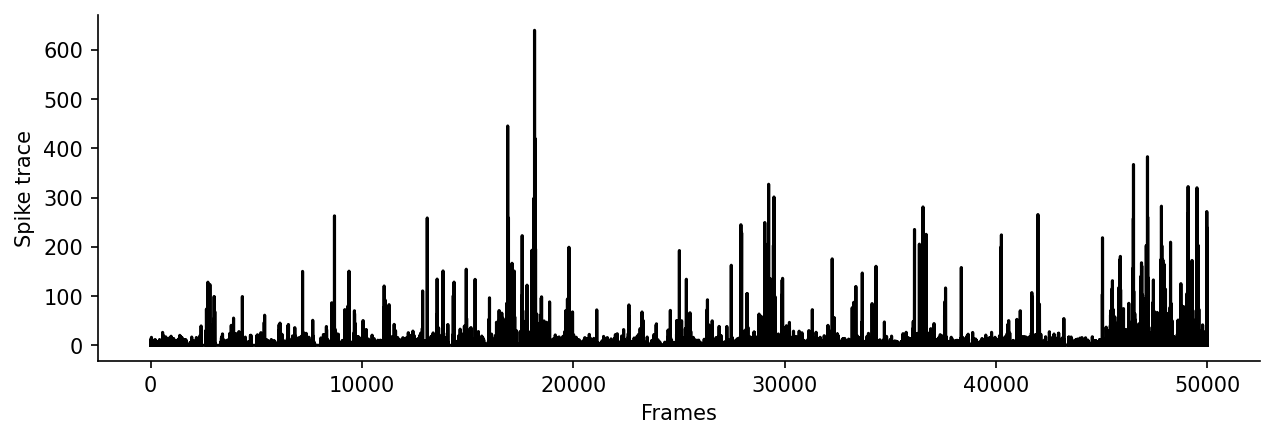

In [ ]:
# noise-constrained deconvolution (OASIS algorithm from CaImAn), applied to the fluorescence traces. values represent inferred spike rates

spike_trace = (nda.Activity() & unit_key).fetch1('trace')

fig, ax = plt.subplots(figsize=(10, 3), dpi=150)
ax.plot(spike_trace, c='k')
ax.set_xlabel('Frames')
ax.set_ylabel('Spike trace')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

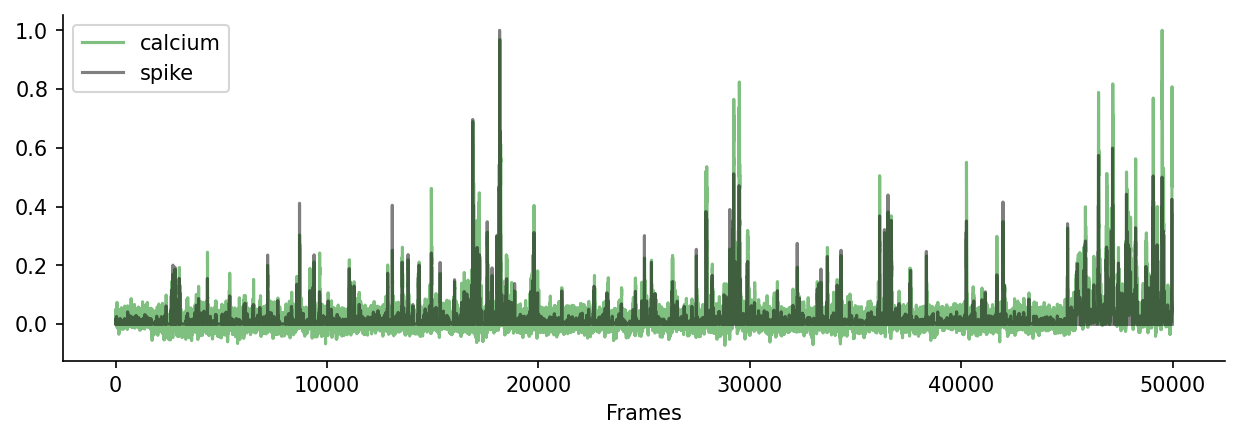

In [ ]:
calcium_trace = (nda.Fluorescence & (nda.ScanUnit & unit_key)).fetch1('trace')

fig, ax = plt.subplots(figsize=(10, 3), dpi=150)
ax.plot(calcium_trace/ np.max(calcium_trace), c='g', alpha=0.5, label='calcium')
ax.plot(spike_trace/ np.max(spike_trace), c='k', label='spike', alpha=0.5)
ax.set_xlabel('Frames')
ax.legend()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

Skip field --> stack --> EM coordinates coregsitration

### Convert entry to DataJoint compatible key

DataJoint tables can be restricted with dictionaries. Here we generate a dictionary of attributes that specify the unique functional ROI in the DataJoint schema. 

In [ ]:
unit_key = entry[['session', 'scan_idx', 'unit_id']].to_dict(orient='records')[0]
unit_key

{'session': 6, 'scan_idx': 6, 'unit_id': 7292}

In [21]:
# for another sample if interested
entry = matched_df.sample(1)
unit_key = entry[['session', 'scan_idx', 'unit_id']].to_dict(orient='records')[0]
unit_key

{'session': 9, 'scan_idx': 4, 'unit_id': 2318}

### Fetch & plot activity trace, calcium trace, pupil radius, and treadmill

Here we use the key to fetch and plot a variety of data from the schema, including the unit's calcium & spike traces, and the scan's pupil trace and treadmill speed. 

Note: The `nda.ManualPupil` and `nda.Treadmill` tables only contain the `session` and `scan_idx` attributes, but can still be retrieved with the `unit_key`. The `unit_id` attribute is ignored when restricting against these tables.

In [63]:
nframes, fps = (nda.Scan & unit_key).fetch1('nframes', 'fps')  # fetch # frames and fps
time_axis = np.arange(nframes)/ fps # create time axis (seconds)
spike_trace = (nda.Activity & unit_key).fetch1('trace') # fetch spike trace
calcium_trace = (nda.ScanUnit * nda.Fluorescence & unit_key).fetch1('trace') # fetch calcium fluorescence trace
pupil_radius = (nda.ManualPupil & unit_key).fetch1('pupil_maj_r') # fetch manually segmented pupil trace 
treadmill = (nda.Treadmill & unit_key).fetch1('treadmill_velocity') # fetch treadmill speed
fps

8.61754

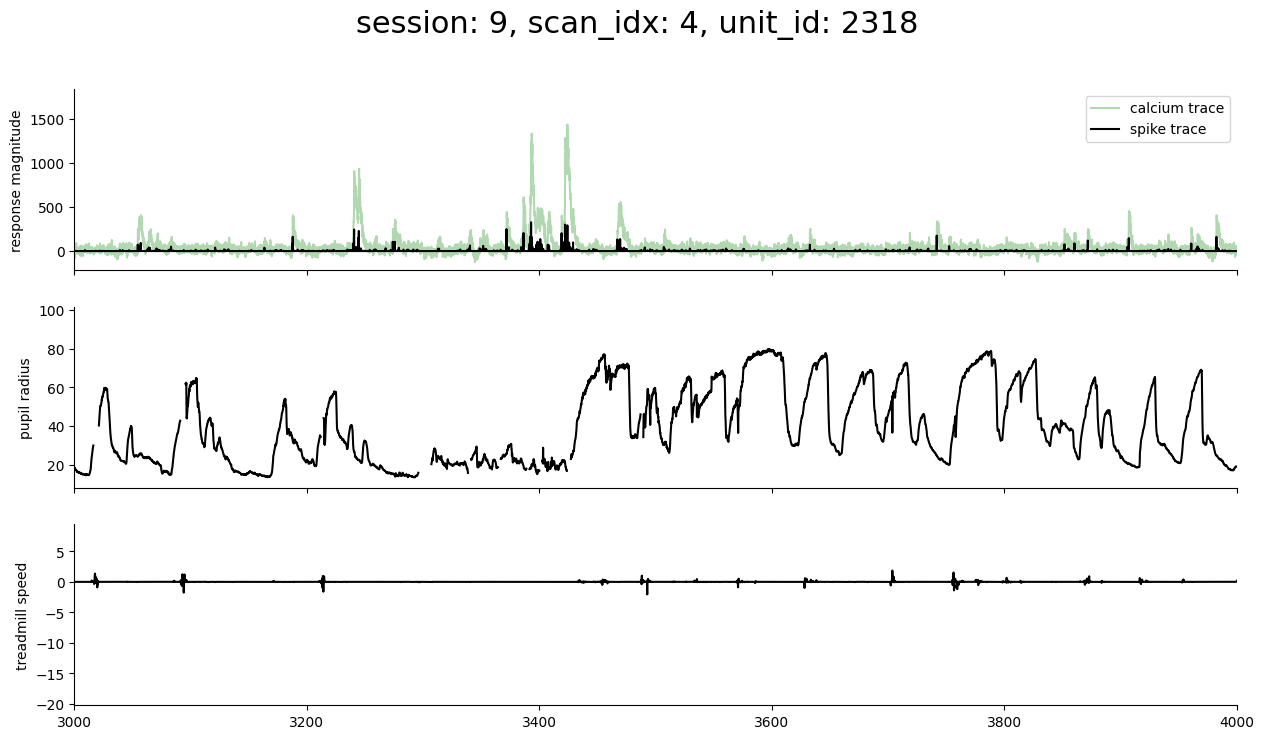

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 8), sharex=True)
ax1.plot(time_axis, calcium_trace, color='g', alpha=0.3, label='calcium trace')
ax1.plot(time_axis, spike_trace, color='k', label='spike trace')
ax2.plot(time_axis, pupil_radius, color='k')
ax3.plot(time_axis, treadmill, color='k')
ax3.set_xlim(3000, 4000) 
ax1.set_ylabel('response magnitude')
ax1.legend()
ax2.set_ylabel('pupil radius (pixels)')
ax3.set_ylabel('treadmill speed')
ax3.set_xlabel('Time (sec)')
fig.suptitle(f'session: {unit_key["session"]}, scan_idx: {unit_key["scan_idx"]}, unit_id: {unit_key["unit_id"]}', fontsize=22);
[ax.spines['right'].set_visible(False) for ax in [ax1, ax2, ax3]];
[ax.spines['top'].set_visible(False) for ax in [ax1, ax2, ax3]];

## Oracle score
The oracle score is a leave-one-out correlation for repeated segments of stimulus. It provides an estimate of visual response reliability for a given unit over the course of the scan. For more detail see the technical documentation found [here](https://www.microns-explorer.org/cortical-mm3#f-data).

Oracle scores are found in `nda.Oracle`. 

*Note that only masks classified as "soma" in `nda.MaskClassification` currently have oracle scores computed. This may change in a future version.*

(7493,)


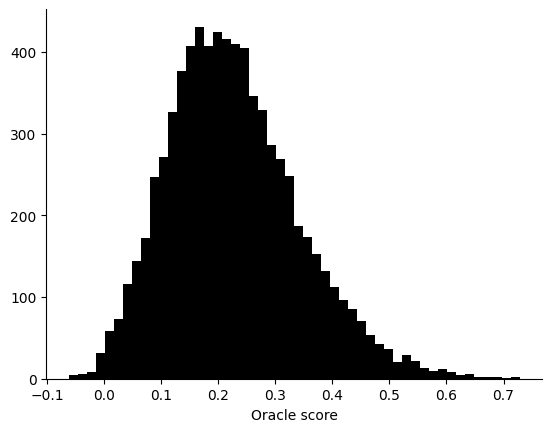

In [58]:
oracles = (nda.Oracle & scan_key).fetch('pearson')
print(oracles.shape)

fig, ax = plt.subplots()
ax.hist(oracles, bins=50, color='k');
ax.set_xlabel("Oracle score")
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

### Plot oracle raster

Here we use a function provided in the `utils` module to retrieve the responses for the functional unit for the repeated stimulus trials (oracle trials). For a further description of the oracle see the technical documentation.

In [59]:
oracle_traces, score = utils.fetch_oracle_raster(unit_key)

Text(0.5, 1.2, 'session: 9, scan_idx: 4, unit_id: 2318')

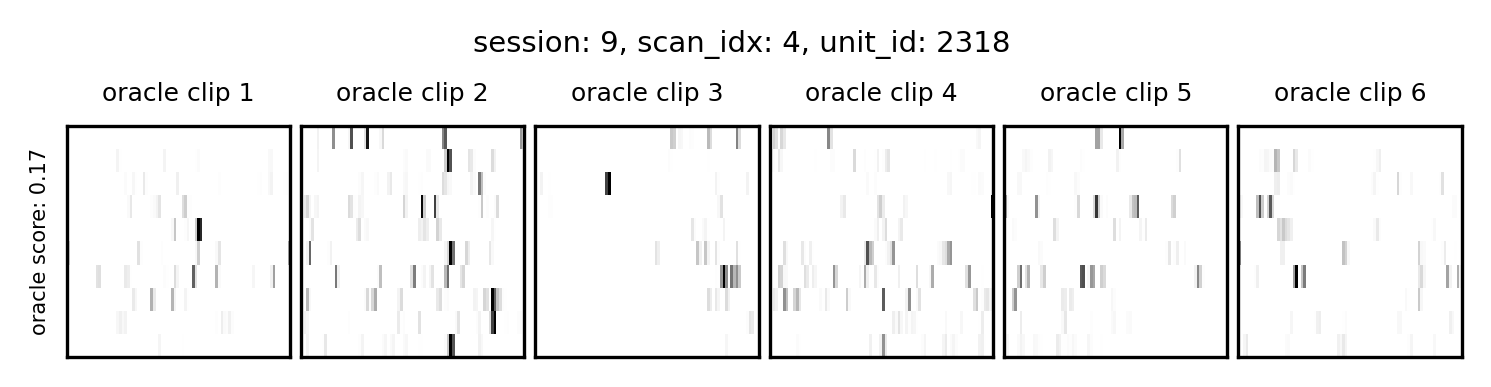

In [60]:
fig,axes = plt.subplots(1,6, figsize=(6,1),dpi=300)
for col,clip_trace in zip(axes,np.moveaxis(oracle_traces,1,0)):
    col.imshow(clip_trace,cmap='binary', interpolation='nearest')
    col.set_aspect('auto')
    col.set_xticks([])
    col.set_yticks([])
axes[0].set_ylabel(f'oracle score: {score:.2f}', fontsize=5)
fig.subplots_adjust(wspace=.05)
[ax.set_title(f'oracle clip {i+1}', fontsize=6) for i, ax in enumerate(axes)];
fig.suptitle(f'session: {unit_key["session"]}, scan_idx: {unit_key["scan_idx"]}, unit_id: {unit_key["unit_id"]}', fontsize=7, y=1.2)

# STOP HERE - REST IS JULIET'S ANALYSES

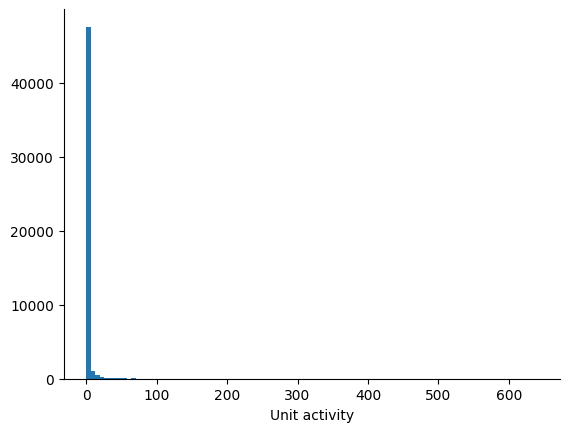

In [ ]:
fig, ax = plt.subplots()
plt.hist(spike_trace, bins = 100)
ax.set_xlabel("Unit activity")
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

In [73]:
entries = matched_df.sample(100)
unit_keys = entries[['session', 'scan_idx', 'unit_id']].to_dict(orient='records')
spike_traces = (nda.Activity() & unit_keys).fetch('trace')

In [86]:
min_len = min(len(t) for t in spike_traces)
X = np.vstack([t[:min_len] for t in spike_traces]) 

In [ ]:
from microns_phase3 import nda, utils
import numpy as np
import matplotlib.pyplot as plt
import datajoint as dj

def compute_area_stats(X):
    """
    Compute mean firing rates and eigenvalues.
    X: (N, T) array — neurons x time, firing rates already given
    """
    X = X.T                              # (T, N) to match MATLAB convention
    meanX = X.mean(axis=0)              # (N,)
    Xcentered = X - meanX

    R = meanX                            # already in firing rate units

    S = np.linalg.svd(Xcentered, compute_uv=False)
    E = S**2 / Xcentered.shape[0]       # eigenvalues, no bin_size scaling

    return {'X': X, 'R': R, 'E': E}


def pr(values):
    values = np.array(values)
    values = values[values > 0]
    return np.sum(values)**2 / np.sum(values**2)


def dhattod(d_hat, alpha):
    """Eliminate the effect of temporal sampling"""
    return d_hat / (1 - alpha * d_hat)


def prdat(eigenvalues, alpha, n_ol):
    """
    Calculate participation ratio from eigenvalue distribution.
    Corrected for temporal sampling and outliers.

    Parameters
    ----------
    eigenvalues : array-like
    alpha       : N / T
    n_ol        : number of outlier eigenvalues to remove from top
    """
    eigenvalues = np.array(eigenvalues)

    if eigenvalues.max() <= 0:
        print('Illegitimate eigenvalues!')
        return 0.0

    eigenvalues = np.sort(eigenvalues)[::-1]  # descending
    eigenvalues = eigenvalues[n_ol:]           # remove top n_ol outliers

    d = pr(eigenvalues)
    d = dhattod(d, alpha)
    return d


def getpr(area_data, n_ol):
    """
    Calculate D(R) and D(C) across chunks after eliminating outliers.

    Parameters
    ----------
    area_data : list of dicts, each with keys 'X', 'R', 'E'
    n_ol      : number of outlier eigenvalues to remove

    Returns
    -------
    DR, DC : arrays of shape (n_chunks,)
    """
    n_chunk = len(area_data)
    DR = np.zeros(n_chunk)
    DC = np.zeros(n_chunk)

    for i, chunk in enumerate(area_data):
        T, N = chunk['X'].shape
        alpha = N / T
        DR[i] = pr(chunk['R'])
        DC[i] = prdat(chunk['E'], alpha, n_ol)

    return DR, DC

Connecting microns@db.datajoint.com:3306


: 

In [ ]:
from collections import defaultdict

session_id = {'session': 4, 'scan_idx': 7}
trials = (nda.Trial & session_id).fetch(
    'trial_idx', 'condition_hash', 'start_idx', 'end_idx',
    as_dict=True
)

# Fetch all unit activity traces: (N, T_full)
unit_ids, traces = (nda.Activity & session_id).fetch('unit_id', 'trace')
X_full = np.vstack(traces)

# Group trials by condition_hash
condition_trials = defaultdict(list)
for trial in trials:
    start = trial['start_idx']
    end = trial['end_idx']
    # condition_trials[trial['condition_hash']].append(X_full[:, start:end])
    condition_trials[trial['condition_hash']].append(X_full)

area_data = []
condition_hashes = []
for condition_hash, trial_list in condition_trials.items():
    stats = compute_area_stats(trial_list[0])
    area_data.append(stats)
    condition_hashes.append(condition_hash)

DR, DC = getpr(area_data, n_ol=1)

plt.figure()
plt.scatter(DR, DC)
plt.xlabel('D(R)')
plt.ylabel('D(C)')
plt.title('Per stimulus condition')


In [12]:
area_data = []
condition_hashes = []
for condition_hash, trial_list in condition_trials.items():
    stats = compute_area_stats(trial_list[0])
    area_data.append(stats)
    condition_hashes.append(condition_hash)

: 

Text(0.5, 1.0, 'Per stimulus condition')

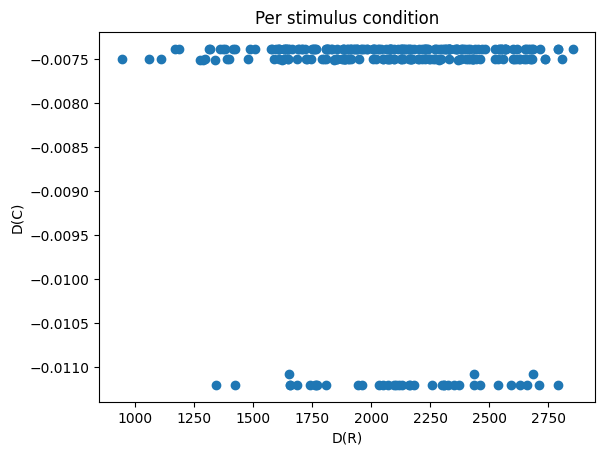

In [6]:
DR, DC = getpr(area_data, n_ol=1)

plt.figure()
plt.scatter(DR, DC)
plt.xlabel('D(R)')
plt.ylabel('D(C)')
plt.title('Per stimulus condition')

In [10]:
(nda.Trial & session_id)

session Session ID,scan_idx Scan ID,trial_idx index of trial within stimulus,type type of stimulus trial,start_idx index of field 1 scan frame at start of trial,end_idx index of field 1 scan frame at end of trial,start_frame_time start time of stimulus frame relative to scan start (seconds),end_frame_time end time of stimulus frame relative to scan start (seconds),stim_times full vector of stimulus frame times relative to scan start (seconds),condition_hash 120-bit hash (The first 20 chars of MD5 in base64)
4,7,0,stimulus.Clip,55,117,8.7030508518219,18.66956400871277,=BLOB=,JEL5/i5FccX4ykUOKaDW
4,7,1,stimulus.Clip,118,181,18.76955008506775,28.736061811447144,=BLOB=,AAQ1HNKGrg1cIXlMw7nz
4,7,2,stimulus.Clip,182,244,28.83605670928955,38.80255699157715,=BLOB=,ksTS42zV+O0YJqa0+s4Y
4,7,3,stimulus.Clip,245,308,38.90255165100098,48.869056224823,=BLOB=,m5JLObtSRnbRKw1ukcSE
4,7,4,stimulus.Clip,309,371,48.9690465927124,58.93554878234863,=BLOB=,L8Z/mji+v1WipuJe4GaL
4,7,5,stimulus.Clip,372,434,59.0355486869812,69.00203704833984,=BLOB=,3+VHi96yg36hu1kI8ZBn
4,7,6,stimulus.Monet2,435,529,69.11870193481445,84.10179495811462,=BLOB=,DKYV7TrfEl+C8nvadH+1
4,7,7,stimulus.Monet2,530,624,84.18511772155762,99.16820192337036,=BLOB=,+rgSVBVRE8Ij1WNhq8ZW
4,7,8,stimulus.Monet2,625,719,99.25153255462646,114.23461866378784,=BLOB=,GHn0W57E+2PS+Qr5yD2r
4,7,9,stimulus.Monet2,720,814,114.31795263290405,129.30104398727417,=BLOB=,u0ftbdrw9UHzSHDe1o4f
